# AI-Based Flood Disaster Assessment System

## Objective

This project combines Sentinel-1 SAR imagery, Google Earth Engine, WorldPop population data, ESA WorldCover land-cover data, and Gemini AI to automatically assess flood impacts and generate disaster reports.

### Study Area
Alappuzha District, Kerala, India

### Event
Kerala Floods 2018

### Technologies
- Google Earth Engine
- Sentinel-1 SAR
- WorldPop
- ESA WorldCover
- Gemini AI
- Python
- Geemap

### Key Results
- Flooded Area: 129.30 km²
- Population Exposed: 145,545
- Flooded Cropland: 18.78 km²

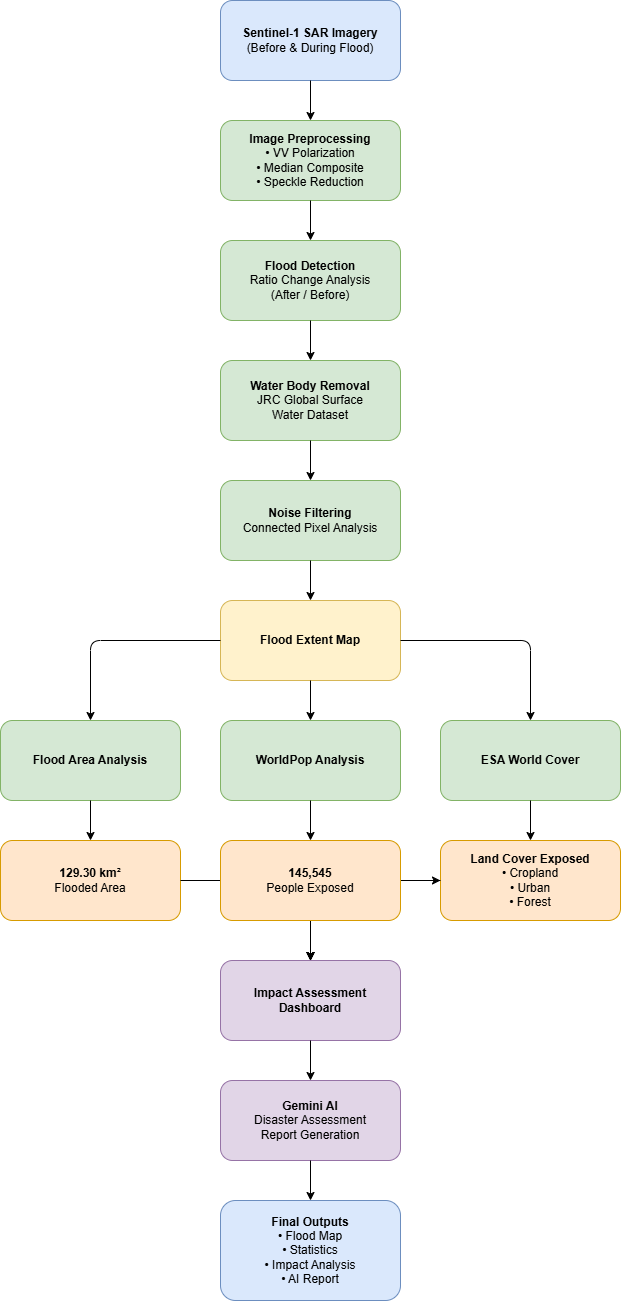

In [1]:
# Install Libraries
!pip install -q earthengine-api geemap google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.9 MB/s eta 0:00:00


In [2]:
# Initialize Earth Engine
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='active-venture-461910-q0')

print("Earth Engine Connected")

Earth Engine Connected


In [3]:
# Study Area
district = (
    ee.FeatureCollection("FAO/GAUL/2015/level2")
    .filter(ee.Filter.eq('ADM1_NAME', 'Kerala'))
    .filter(ee.Filter.eq('ADM2_NAME', 'Alappuzha'))
)

In [4]:
# Sentinel-1 Data
# Before Flood
before = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(district)
    .filterDate('2018-07-20', '2018-08-05')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .select('VV')
    .median()
)

In [5]:
# During Flood
after = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(district)
    .filterDate('2018-08-15', '2018-08-25')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .select('VV')
    .median()
)

In [6]:
# Flood Detection
before_f = before.focal_mean(30, 'circle', 'meters')
after_f = after.focal_mean(30, 'circle', 'meters')

ratio = after_f.divide(before_f)

flood = ratio.lt(0.8)

In [7]:
# Permanent Water Removal
water = (
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
    .select('occurrence')
    .gt(90)
)

flood = flood.And(water.Not())


In [8]:
# Noise Removal
flood = flood.connectedPixelCount(100).gte(8)

In [9]:
# Flood Map
Map = geemap.Map()

Map.centerObject(district, 10)

Map.addLayer(
    flood.selfMask().clip(district),
    {'palette':['blue']},
    'Flood Extent'
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

In [10]:
# Flood Area Calculation
pixel_area = ee.Image.pixelArea()

flood_area = (
    flood.multiply(pixel_area)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=district.geometry(),
        scale=10,
        maxPixels=1e13
    )
)

area_m2 = list(flood_area.getInfo().values())[0]

area_km2 = area_m2 / 1e6

print(f"Flooded Area: {area_km2:.2f} km²")

Flooded Area: 129.30 km²


In [11]:
# Population Exposure
population = (
    ee.ImageCollection("WorldPop/GP/100m/pop")
    .filter(ee.Filter.eq('country', 'IND'))
    .first()
)

flood_mask = flood.selfMask()

affected_population = population.multiply(flood_mask)

pop_stats = affected_population.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=district.geometry(),
    scale=100,
    maxPixels=1e13
)

affected_people = list(pop_stats.getInfo().values())[0]

print(f"Population Exposed: {affected_people:,.0f}")

Population Exposed: 145,545


In [12]:
# Flood Percentage
district_area = district.geometry().area().getInfo() / 1e6

flood_percent = (area_km2 / district_area) * 100

print(f"District Area: {district_area:.2f} km²")
print(f"Flooded Percentage: {flood_percent:.2f}%")

District Area: 1316.69 km²
Flooded Percentage: 9.82%


In [13]:
# Gemini Report
from google.colab import userdata
from google import genai

API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=API_KEY)

In [14]:
prompt = f"""
Generate a professional disaster assessment report.

Study Area: Alappuzha District, Kerala, India
Event: Kerala Floods 2018

Results:
- Flooded Area: 129.30 km²
- District Area: 1316.69 km²
- Flooded Percentage: 9.82%
- Total Population: 1.81 Million
- Estimated Population Exposed: 145,545 people

Include:
1. Executive Summary
2. Methodology
3. Key Findings
4. Population Impact
5. Disaster Risk Assessment
6. Recommendations
7. Conclusion

Use professional GIS, Remote Sensing and Disaster Management terminology.
"""

In [15]:
report = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(report.text)

## Disaster Assessment Report: Kerala Floods 2018 - Alappuzha District

**Report Date:** October 26, 2023
**Prepared For:** District Disaster Management Authority, Alappuzha
**Prepared By:** [Your Organization/Department Name, e.g., Geospatial Analysis & Disaster Management Unit]
**Contact:** [Your Contact Information]

---

### 1. Executive Summary

This report presents a comprehensive disaster assessment for Alappuzha District, Kerala, following the unprecedented Kerala Floods of August 2018. Leveraging advanced Geographic Information Systems (GIS) and Remote Sensing (RS) technologies, this analysis quantifies the extent of inundation and its immediate impact on the population. The study reveals that 129.30 km² (9.82%) of Alappuzha District's total area (1316.69 km²) was submerged, directly exposing an estimated 145,545 people to floodwaters. The district's unique low-lying topography, dense population, and reliance on water-dependent livelihoods rendered it highly vulnerable to the 

In [16]:
worldcover = ee.Image("ESA/WorldCover/v200/2021")

Map = geemap.Map()
Map.centerObject(district, 10)

Map.addLayer(
    worldcover.clip(district),
    {},
    "WorldCover"
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

In [18]:
cropland = worldcover.eq(40)

flooded_cropland = flood.And(cropland)

In [19]:
cropland_area = (
    flooded_cropland
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=district.geometry(),
        scale=10,
        maxPixels=1e13
    )
)

cropland_km2 = list(cropland_area.getInfo().values())[0] / 1e6

print(f"Flooded Cropland: {cropland_km2:.2f} km²")

Flooded Cropland: 18.78 km²


In [20]:
urban = worldcover.eq(50)

flooded_urban = flood.And(urban)

urban_area = (
    flooded_urban
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=district.geometry(),
        scale=10,
        maxPixels=1e13
    )
)

urban_km2 = list(urban_area.getInfo().values())[0] / 1e6

print(f"Flooded Urban Area: {urban_km2:.2f} km²")

Flooded Urban Area: 0.03 km²


In [21]:
forest = worldcover.eq(10)

flooded_forest = flood.And(forest)

forest_area = (
    flooded_forest
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=district.geometry(),
        scale=10,
        maxPixels=1e13
    )
)

forest_km2 = list(forest_area.getInfo().values())[0] / 1e6

print(f"Flooded Forest Area: {forest_km2:.2f} km²")

Flooded Forest Area: 0.48 km²


In [22]:
high_flood = ratio.lt(0.60)

In [23]:
moderate_flood = (
    ratio.gte(0.60)
    .And(ratio.lt(0.70))
)

In [24]:
low_flood = (
    ratio.gte(0.70)
    .And(ratio.lt(0.80))
)

In [25]:
water = (
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
    .select('occurrence')
    .gt(90)
)

high_flood = high_flood.And(water.Not())
moderate_flood = moderate_flood.And(water.Not())
low_flood = low_flood.And(water.Not())

In [26]:
Map = geemap.Map()

Map.centerObject(district, 10)

Map.addLayer(
    low_flood.selfMask().clip(district),
    {'palette':['yellow']},
    'Low Severity'
)

Map.addLayer(
    moderate_flood.selfMask().clip(district),
    {'palette':['orange']},
    'Moderate Severity'
)

Map.addLayer(
    high_flood.selfMask().clip(district),
    {'palette':['red']},
    'High Severity'
)

Map

Map(center=[9.417966364135447, 76.4434611887918], controls=(WidgetControl(options=['position', 'transparent_bg…

In [27]:
def calculate_area(mask):

    area = (
        mask.multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=district.geometry(),
            scale=10,
            maxPixels=1e13
        )
    )

    return list(area.getInfo().values())[0] / 1e6

In [28]:
low_area = calculate_area(low_flood)

moderate_area = calculate_area(moderate_flood)

high_area = calculate_area(high_flood)

print(f"Low Severity: {low_area:.2f} km²")
print(f"Moderate Severity: {moderate_area:.2f} km²")
print(f"High Severity: {high_area:.2f} km²")

Low Severity: 8.65 km²
Moderate Severity: 2.28 km²
High Severity: 0.25 km²


In [30]:
high_flood = ratio.lt(0.80)

moderate_flood = (
    ratio.gte(0.80)
    .And(ratio.lt(0.90))
)

low_flood = (
    ratio.gte(0.90)
    .And(ratio.lt(1.00))
)

In [31]:
high_flood = ratio.lt(0.70)

moderate_flood = (
    ratio.gte(0.70)
    .And(ratio.lt(0.85))
)

low_flood = (
    ratio.gte(0.85)
    .And(ratio.lt(1.00))
)

In [32]:
print("="*50)
print("FLOOD IMPACT SUMMARY")
print("="*50)

print(f"Flooded Area: {area_km2:.2f} km²")
print(f"District Area: {district_area:.2f} km²")
print(f"Flood Percentage: {flood_percent:.2f}%")

print()

print(f"Population Exposed: {affected_people:,.0f}")

print()

print(f"Flooded Cropland: {cropland_km2:.2f} km²")
print(f"Flooded Urban Area: {urban_km2:.2f} km²")
print(f"Flooded Forest Area: {forest_km2:.2f} km²")

FLOOD IMPACT SUMMARY
Flooded Area: 129.30 km²
District Area: 1316.69 km²
Flood Percentage: 9.82%

Population Exposed: 145,545

Flooded Cropland: 18.78 km²
Flooded Urban Area: 0.03 km²
Flooded Forest Area: 0.48 km²


In [33]:
prompt = f"""
You are a GIS and Disaster Management expert.

Generate a professional Flood Disaster Assessment Report.

Study Area:
Alappuzha District, Kerala, India

Event:
Kerala Floods 2018

Analysis Results:
- Flooded Area: {area_km2:.2f} km²
- District Area: {district_area:.2f} km²
- Flooded Percentage: {flood_percent:.2f}%
- Population Exposed: {affected_people:,.0f}
- Flooded Cropland: {cropland_km2:.2f} km²
- Flooded Urban Area: {urban_km2:.2f} km²
- Flooded Forest Area: {forest_km2:.2f} km²

Prepare the report with the following sections:

1. Executive Summary
2. Study Area Description
3. Methodology
4. Flood Extent Analysis
5. Population Exposure Assessment
6. Land Use/Land Cover Impact Analysis
7. Risk Assessment
8. Recommendations
9. Conclusion

Use professional GIS, Remote Sensing, and Disaster Management terminology.
The report should be suitable for government agencies and disaster management authorities.
"""

In [34]:
report = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

report_text = report.text

print(report_text)

## Flood Disaster Assessment Report: Alappuzha District, Kerala, India - Kerala Floods 2018

**Prepared for:**
Government of Kerala
State Disaster Management Authority (SDMA)
District Disaster Management Authority (DDMA), Alappuzha

**Date:** [Insert Current Date]

---

### 1. Executive Summary

This report presents a comprehensive geospatial assessment of the impacts of the devastating Kerala Floods of 2018 on Alappuzha District. Utilizing advanced Remote Sensing and Geographic Information Systems (GIS) techniques, the analysis reveals that a significant portion of the district was inundated, causing widespread disruption and exposing a substantial population to flood hazards. Approximately **129.30 km² (9.82%)** of the total district area was submerged. The assessment identifies **145,545 individuals** as exposed to flooding, with profound impacts on agricultural lands and livelihoods, particularly in the low-lying Kuttanad region. While urban and forest areas experienced comparative

# Conclusion

The analysis identified:

- 129.30 km² of inundated land
- Approximately 145,545 exposed residents
- Significant impact on agricultural land
- Limited impact on forested and urban regions

The integration of SAR imagery, population datasets, land-cover analysis, and Generative AI demonstrates a scalable framework for rapid disaster assessment.